In [305]:
# to autoimport edited modules in the notebook
%load_ext autoreload
%autoreload 2

from grsc_cb_model import GRSC_CB_Model
from grsc_cb_instance import GRSC_CB_Instance
import numpy as np
from scipy.spatial import Delaunay, ConvexHull
import networkx as nx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [306]:
# number of land parcels
n = 30
# number of species
m = 12
# number of max connected areas
k = 3
# range of habitat suitability function
w_min, w_max = 20, 100
# range of costs
c_min, c_max = 1, 100
# lambda percentage threshold
lambda_threshold = 0.05
# buffer size
d = 1

External nodes: [6, 7, 8, 10, 16, 20, 21, 26, 27, 28]


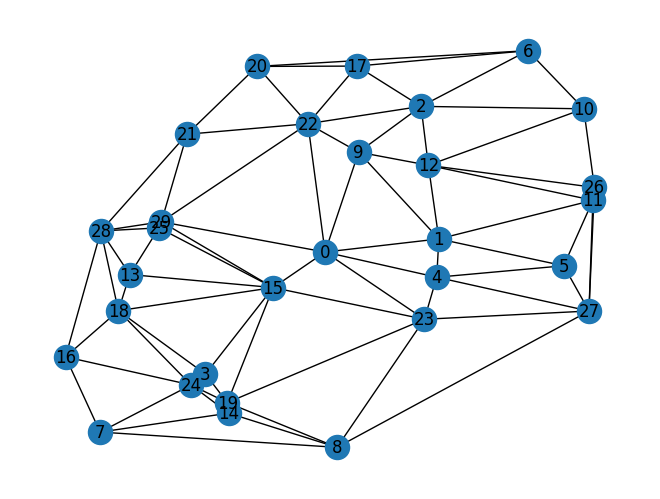

In [307]:
# generate a random instance Delunay graph
points = np.random.rand(n, 2)
tri = Delaunay(points)

G = nx.Graph()
G.add_nodes_from(range(len(points)))

# for each node, it connects it to its neighbors using Delaunay triangulation
for simplex in tri.simplices:
    i, j, k = simplex
    G.add_edge(i, j)
    G.add_edge(j, k)
    G.add_edge(i, k)

# determines the set of external nodes  
external_nodes = set(ConvexHull(points).vertices)
nx.draw(G, points, with_labels=True)
print(f"External nodes: {[int(i) for i in external_nodes]}")

In [308]:
# costs of land parcels
c = {i: np.random.randint(c_min, c_max + 1) for i in G.nodes}

In [309]:
# specie definition
S_1 = list(range(m//2))
S_2 = list(range(m//2, m))
P_1 = len(S_1)
P_2 = len(S_2) // 2

# habitat suitability score function
w = {}
for s in S_1 + S_2:
    prob_zero = 0.2 if s in S_1 else 0.1
    for i in G.nodes:
        if i in external_nodes and s in S_1:
            w[(i, s)] = 0
        elif np.random.rand() < prob_zero:
            w[(i, s)] = 0
        else:
            w[(i, s)] = np.random.randint(w_min, w_max + 1)
            
# suitability quota
lambda_s = {s: lambda_threshold * sum(w[(i, s)] for i in G.nodes) for s in S_1 + S_2}

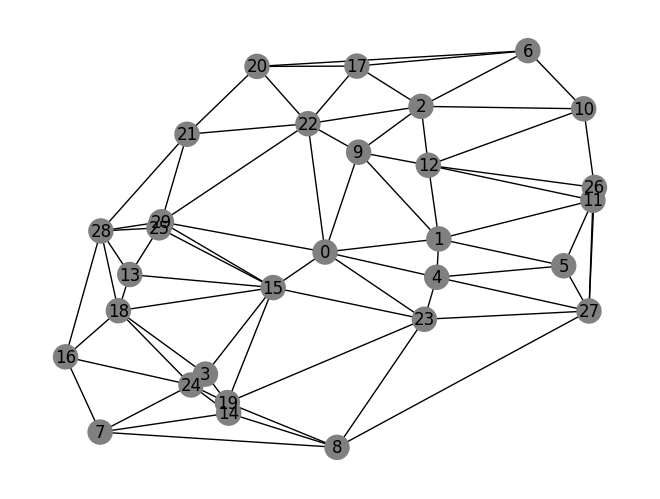

In [310]:
# toy instance
V, E = G.nodes, G.edges
instance = GRSC_CB_Instance(V, E, points, 
                            S_1, S_2, P_1, P_2, 
                            k, w, lambda_s, c, d)

instance.draw_graph()


Status: 2
Objective: 337.0
Nodes in the reserve (x): [3, 7, 8, 14, 15, 19, 23, 24]
Nodes in the core (z): [14, 19]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11]


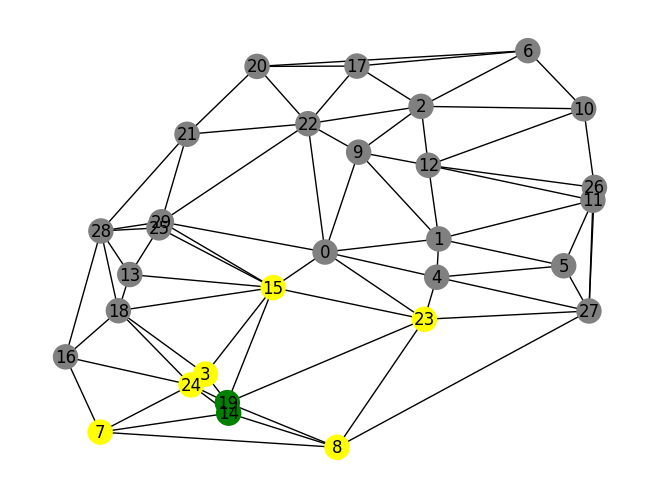

In [311]:
model = GRSC_CB_Model(instance)
model.solve()
model.print_solution()
model.print_graph()

In [312]:
print(nx.node_boundary(G, G))

set()
